In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [11]:
import warnings
warnings.filterwarnings('ignore')

In [12]:
# Cargar y preparar los datos
df = pd.read_csv('Entregable1.csv', low_memory=False)

In [13]:
df.head()

,MANUFACTURER,BRAND,ITEM_CODE,ITEM_DESCRIPTION,ID_CATEGORY,FORMAT,ATTR1,ATTR2,ATTR3,WEEK,...,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION,CATEGORY,SEGMENT,YEAR,MONTH,WEEK_NUMBER,DATE,UNIT_PRICE
0,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL,1,LIQUIDO,CLORO,CLORO,NaN,45-22,...,0.142,8.500,TOTAL AUTOS SCANNING MEXICO,FABRIC TREATMENT & SANITATION,BLEACH,2022,11,45,2022-11-13,4.176471
1,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL,1,LIQUIDO,CLORO,CLORO,NaN,48-22,...,0.009,1.000,TOTAL AUTOS SCANNING MEXICO,FABRIC TREATMENT & SANITATION,BLEACH,2022,12,48,2022-12-04,4.500000
2,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL,1,LIQUIDO,CLORO,CLORO,NaN,03-22,...,1.956,14.400,TOTAL AUTOS SCANNING MEXICO,FABRIC TREATMENT & SANITATION,BLEACH,2022,1,3,2022-01-23,4.527778
3,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL,1,LIQUIDO,CLORO,CLORO,NaN,05-22,...,0.779,11.095,TOTAL AUTOS SCANNING MEXICO,FABRIC TREATMENT & SANITATION,BLEACH,2022,2,5,2022-02-06,3.343348
4,INDS. ALEN,CLORALEX,0000075000592,CLORALEX EL RENDIDOR BOT.PLAST. 250ML NAL,1,LIQUIDO,CLORO,CLORO,NaN,09-22,...,0.251,5.500,TOTAL AUTOS SCANNING MEXICO,FABRIC TREATMENT & SANITATION,BLEACH,2022,3,9,2022-03-06,4.563636


In [14]:
from sklearn.preprocessing import StandardScaler

# Seleccionar las características para el clustering
features = ['TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES']

# Estandarizar las características
data = df[features]
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

In [15]:
df_scaled = pd.DataFrame(scaled_data, columns=[f"{col}_SCALED" for col in features])

In [16]:
df_scaled.head()

,TOTAL_UNIT_SALES_SCALED,TOTAL_VALUE_SALES_SCALED
0,-0.219171,-0.258032
1,-0.221379,-0.258411
2,-0.191715,-0.252852
3,-0.205443,-0.256213
4,-0.217723,-0.257721


In [17]:
fields = df_scaled.values

In [18]:
wcss = []
for index in range(1, 11):
    kmeans = KMeans(n_clusters = index, init = 'k-means++', random_state = 2)
    kmeans.fit(fields)

    wcss.append(kmeans.inertia_)

Text(0, 0.5, 'WCSS')

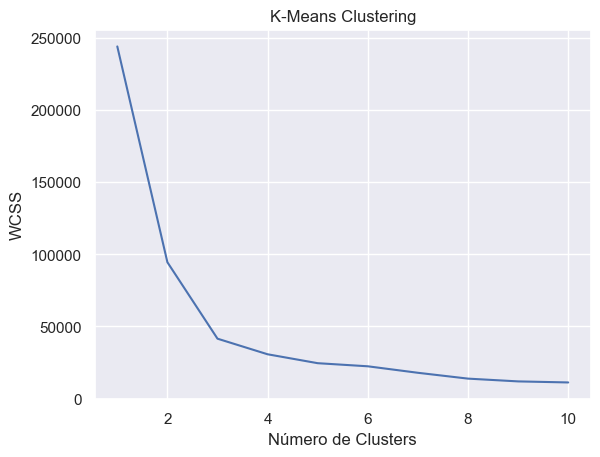

In [19]:
# Graficación del "Codo de Jambu"
sns.set()
plt.plot(range(1,11), wcss)
plt.title('K-Means Clustering')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS') # Weighted Clusters Sum of Squares

In [20]:
# Evaluar los resultados del clustering
# Asigna cada producto a un cluster
kmeans = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42)
cluster_values = kmeans.fit_predict(fields)
print(cluster_values)

[0 0 0 ... 0 0 0]


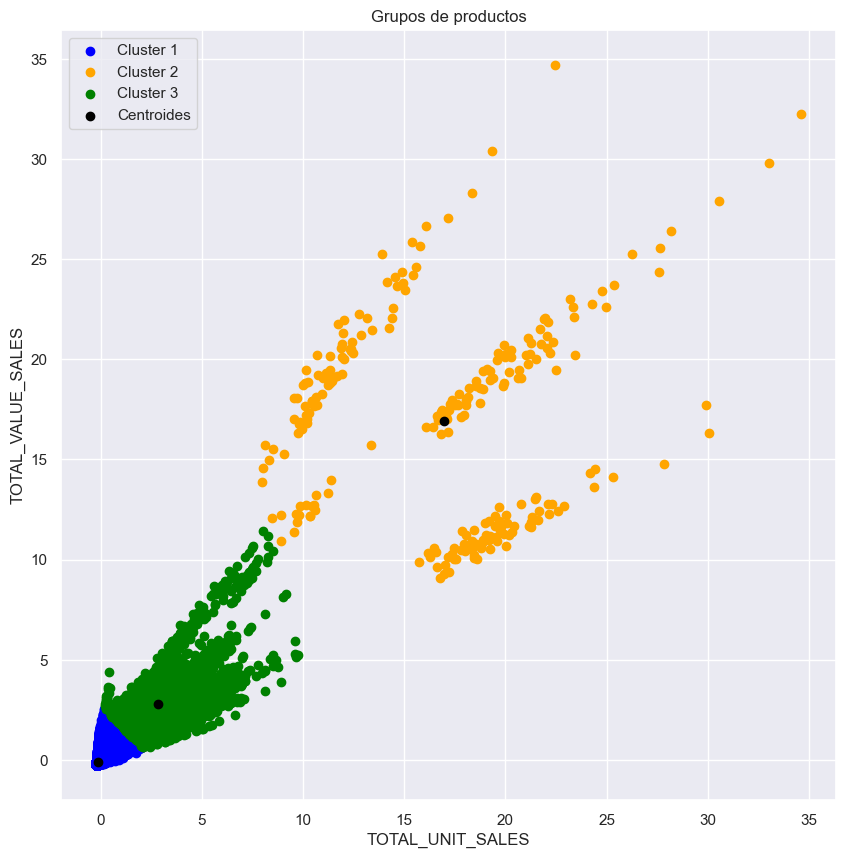

In [21]:
# Visualizar los clusters
plt.figure(figsize=(10,10))
plt.scatter(fields[cluster_values==0, 0], fields[cluster_values==0, 1], c = 'blue', label = 'Cluster 1')
plt.scatter(fields[cluster_values==1, 0], fields[cluster_values==1, 1], c = 'orange', label = 'Cluster 2')
plt.scatter(fields[cluster_values==2, 0], fields[cluster_values==2, 1], c = 'green', label = 'Cluster 3')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:,1], c='black', label='Centroides')

plt.title('Grupos de productos')
plt.xlabel('TOTAL_UNIT_SALES')
plt.ylabel('TOTAL_VALUE_SALES')
plt.legend()

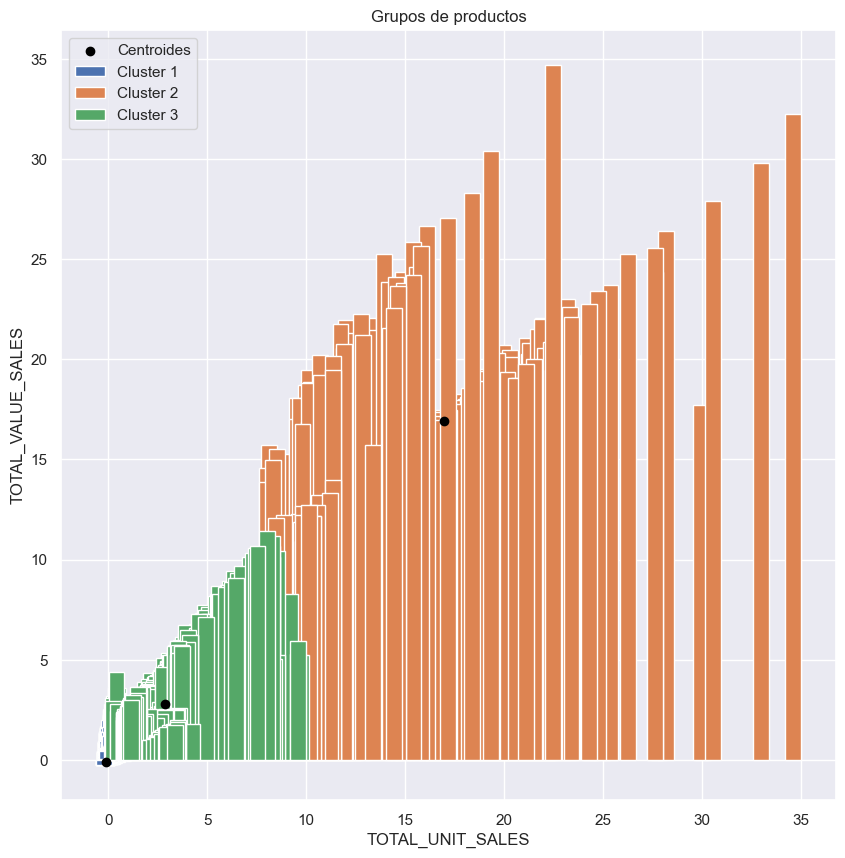

In [23]:
# Visualizar los clusters
plt.figure(figsize=(10,10))
plt.bar(fields[cluster_values==0, 0], fields[cluster_values==0, 1], label = 'Cluster 1')
plt.bar(fields[cluster_values==1, 0], fields[cluster_values==1, 1], label = 'Cluster 2')
plt.bar(fields[cluster_values==2, 0], fields[cluster_values==2, 1], label = 'Cluster 3')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:,1], c='black', label='Centroides')

plt.title('Grupos de productos')
plt.xlabel('TOTAL_UNIT_SALES')
plt.ylabel('TOTAL_VALUE_SALES')
plt.legend()

In [25]:
df['CLUSTER'] = cluster_values

In [34]:
# Interpretar y analizar los clusters
vanish = df[(df['BRAND'] == 'VANISH') & (df['CLUSTER'] == 2)]
vanish = pd.DataFrame(vanish.groupby('ITEM_DESCRIPTION'))
vanish

,0,1
0,VANISH BOT. 4000 ML,MANUFACTURER BRAND ITEM_CODE ...
1,VANISH CRYSTAL WHITE QUITAMANCHAS GEL POUCH 45...,MANUFACTURER BRAND ITEM_CODE \ 5...
2,VANISH INTELLIGENCE POLVO BOTE 450 GR NAL,MANUFACTURER BRAND ITEM_CODE \ 6...
3,VANISH LIQUIDO BOTELLA 925ML NAL,MANUFACTURER BRAND ITEM_CODE ...
4,VANISH PODER O2 CRYSTAL WHITE BOTE 450 GR,MANUFACTURER BRAND ITEM_CODE \ 6...
5,VANISH PODER O2 CRYSTAL WHITE DOYPACK 120 GR,MANUFACTURER BRAND ITEM_CODE \ 6...
6,VANISH ROSA COLOR LIQ. DOYPACK 650ML NAL,MANUFACTURER BRAND ITEM_CODE \ 6...
7,VANISH ROSA QUITAMANCHAS GEL BOT 3.8 LT PROM ESP,MANUFACTURER BRAND ITEM_CODE \ 5...
8,VANISH ROSA QUITAMANCHAS GEL MULTIUSOS POUCH 4...,MANUFACTURER BRAND ITEM_CODE \ 5...
9,VANISH SUPER BARRA QUITA MANCHAS 68GR,MANUFACTURER BRAND ITEM_CODE \ 4...


## Documenta los insights clave de los resultados. Por ejemplo, ¿hay segmentos donde la marca Vanish tiene un fuerte desempeño? ¿Qué clusters muestran un rendimiento bajo o áreas de mejora?
Podemos observar que la marca Vanish cuenta con 10 productos con un fuerte desempeño ya que estos se encuentran en el grupo de cluster 2, es decir que sus ventas han sido altas.
Por otra parte, los clusters que muestran un desempeño bajo o área de mejora son el 1 y el 3. Tambien se puede ver en el grafico de dispersion que son los grupos que mas predominan.

Exite una característica en común que podría explicar ese desempeño, el numero de unidades vendidas esta directamente relacionada con las ventas totales del producto.

In [26]:
# Guardar los resultados y el modelo
df.to_csv('Entregable3.csv', index=False)